# 2026 Wildfire Survival EDA

This notebook is the first-pass exploratory analysis for the wildfire survival forecasting task. The goal is to validate the raw data contract, inspect target behavior, and identify the highest-value modeling considerations before building folds and baselines.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 140)

In [2]:
project_root = Path.cwd()
if project_root.name == "notebooks":
    project_root = project_root.parent

raw_dir = project_root / "data" / "raw"
train = pd.read_csv(raw_dir / "train.csv")
test = pd.read_csv(raw_dir / "test.csv")
meta = pd.read_csv(raw_dir / "metaData.csv")
sample_submission = pd.read_csv(raw_dir / "sample_submission.csv")

print("project_root:", project_root)
print("train shape:", train.shape)
print("test shape:", test.shape)
print("metadata shape:", meta.shape)
print("sample submission shape:", sample_submission.shape)

project_root: c:\Users\Admin\Documents\Datathon\2026
train shape: (221, 37)
test shape: (95, 35)
metadata shape: (37, 6)
sample submission shape: (95, 5)


## 1. Schema And Data Contract

In [3]:
shared_cols = sorted(set(train.columns).intersection(test.columns))
train_only_cols = sorted(set(train.columns) - set(test.columns))
test_only_cols = sorted(set(test.columns) - set(train.columns))
feature_cols = [c for c in train.columns if c not in ["event_id", "event", "time_to_hit_hours"]]

display(pd.Series({
    "train_rows": len(train),
    "test_rows": len(test),
    "train_columns": train.shape[1],
    "test_columns": test.shape[1],
    "shared_columns": len(shared_cols),
    "train_only_columns": ", ".join(train_only_cols),
    "test_only_columns": ", ".join(test_only_cols) if test_only_cols else "None",
    "modeling_feature_count": len(feature_cols),
}))

display(meta.groupby(["type", "category"]).size().rename("count").reset_index())

train_rows                                     221
test_rows                                       95
train_columns                                   37
test_columns                                    35
shared_columns                                  35
train_only_columns        event, time_to_hit_hours
test_only_columns                             None
modeling_feature_count                          34
dtype: object

,type,category,count
0,feature,centroid_kinematics,5
1,feature,directionality,4
2,feature,distance,9
3,feature,growth,10
4,feature,temporal_coverage,3
5,feature,temporal_metadata,3
6,identifier,identifier,1
7,target,target,2


In [4]:
quality_checks = pd.Series({
    "missing_values_train": int(train.isna().sum().sum()),
    "missing_values_test": int(test.isna().sum().sum()),
    "duplicate_event_id_train": int(train["event_id"].duplicated().sum()),
    "duplicate_event_id_test": int(test["event_id"].duplicated().sum()),
    "shared_event_ids_between_train_and_test": len(set(train["event_id"]).intersection(set(test["event_id"]))),
})

display(quality_checks)
display(train.head(3))

missing_values_train                       0
missing_values_test                        0
duplicate_event_id_train                   0
duplicate_event_id_test                    0
shared_event_ids_between_train_and_test    0
dtype: int64

,event_id,num_perimeters_0_5h,dt_first_last_0_5h,low_temporal_resolution_0_5h,area_first_ha,area_growth_abs_0_5h,area_growth_rel_0_5h,area_growth_rate_ha_per_h,log1p_area_first,log1p_growth,log_area_ratio_0_5h,relative_growth_0_5h,radial_growth_m,radial_growth_rate_m_per_h,centroid_displacement_m,centroid_speed_m_per_h,spread_bearing_deg,spread_bearing_sin,spread_bearing_cos,dist_min_ci_0_5h,dist_std_ci_0_5h,dist_change_ci_0_5h,dist_slope_ci_0_5h,closing_speed_m_per_h,closing_speed_abs_m_per_h,projected_advance_m,dist_accel_m_per_h2,dist_fit_r2_0_5h,alignment_cos,alignment_abs,cross_track_component,along_track_speed,event_start_hour,event_start_dayofweek,event_start_month,time_to_hit_hours,event
0,10892457,3,4.265188,0,79.696304,2.875935,0.036086,0.674281,4.390693,1.354787,0.03545,0.036086,9.007182,2.11179,8.274971,1.940119,70.130507,0.940469,0.339879,6166.121596,0.205085,0.435052,1.090997e-01,-0.102001,0.102001,-0.435052,7.275611e-02,0.886373,-0.054649,0.054649,-1.937219,-0.106026,19,4,5,18.892512,0
1,11757157,2,1.169918,0,8.946749,0.000000,0.000000,0.000000,2.297246,0.000000,0.00000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,1.000000,2930.925956,0.000000,0.000000,-3.887003e-13,0.000000,0.000000,0.000000,0.000000e+00,0.000000,-0.568898,0.568898,-0.000000,-0.000000,4,4,6,22.048108,1
2,11945086,4,4.777526,0,106.482638,0.000000,0.000000,0.000000,4.677329,0.000000,0.00000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,1.000000,3272.375090,0.000000,0.000000,-1.390327e-13,0.000000,0.000000,0.000000,7.965118e-14,0.000000,0.882385,0.882385,0.000000,0.000000,22,4,8,0.888895,1


## 2. Survival Target Snapshot

In [5]:
event_rate = train["event"].mean()
censoring_rate = 1 - event_rate

display(pd.Series({
    "event_rate": round(event_rate, 6),
    "censoring_rate": round(censoring_rate, 6),
    "time_mean": round(train["time_to_hit_hours"].mean(), 6),
    "time_median": round(train["time_to_hit_hours"].median(), 6),
    "time_max": round(train["time_to_hit_hours"].max(), 6),
}))

display(train["time_to_hit_hours"].describe())

event_rate         0.312217
censoring_rate     0.687783
time_mean         37.567626
time_median       43.109830
time_max          66.994474
dtype: float64

count    221.000000
mean      37.567626
std       25.902361
min        0.001220
25%       12.242322
50%       43.109830
75%       63.938706
max       66.994474
Name: time_to_hit_hours, dtype: float64

In [6]:
horizon_rows = []
for horizon in [12, 24, 48, 72]:
    horizon_rows.append({
        "horizon_hours": horizon,
        "observed_positive_rate": ((train["event"] == 1) & (train["time_to_hit_hours"] <= horizon)).mean(),
        "known_negative_rate": (train["time_to_hit_hours"] > horizon).mean(),
        "censored_at_or_before_horizon_rate": ((train["event"] == 0) & (train["time_to_hit_hours"] <= horizon)).mean(),
    })

display(pd.DataFrame(horizon_rows).round(4))

,horizon_hours,observed_positive_rate,known_negative_rate,censored_at_or_before_horizon_rate
0,12,0.2217,0.7511,0.0271
1,24,0.2851,0.6018,0.1131
2,48,0.2986,0.4525,0.2489
3,72,0.3122,0.0000,0.6878


## 3. Operational Slices

In [7]:
display(train.groupby("low_temporal_resolution_0_5h")["event"].agg(["count", "mean"]).round(4))
display(train.groupby("event_start_month")["event"].agg(["count", "mean"]).round(4))
display(train.groupby("event_start_dayofweek")["event"].agg(["count", "mean"]).round(4))

,count,mean
low_temporal_resolution_0_5h,,
0,60,0.600
1,161,0.205


,count,mean
event_start_month,,
1,1,1.0000
2,1,0.0000
3,14,0.0714
4,6,0.1667
5,14,0.3571
6,33,0.3333
7,68,0.3235
8,70,0.3143
9,14,0.4286


,count,mean
event_start_dayofweek,,
0,31,0.3548
1,37,0.4324
2,35,0.3143
3,39,0.3333
4,20,0.2500
5,30,0.1000
6,29,0.3448


## 4. Simple Train/Test Drift Check

In [8]:
drift = pd.DataFrame({
    "train_missing": train[feature_cols].isna().sum(),
    "test_missing": test[feature_cols].isna().sum(),
    "train_mean": train[feature_cols].mean(),
    "test_mean": test[feature_cols].mean(),
    "train_std": train[feature_cols].std(),
})
drift["abs_mean_shift_over_std"] = (
    (drift["train_mean"] - drift["test_mean"]).abs() / drift["train_std"].replace(0, pd.NA)
).fillna(0)

display(drift.sort_values("abs_mean_shift_over_std", ascending=False).head(10).round(4))

,train_missing,test_missing,train_mean,test_mean,train_std,abs_mean_shift_over_std
area_first_ha,0,0,619.1316,891.2998,1447.7237,0.1880
event_start_dayofweek,0,0,2.8416,2.5474,1.9742,0.1491
radial_growth_rate_m_per_h,0,0,7.7703,2.3343,37.8405,0.1437
alignment_abs,0,0,0.1727,0.1280,0.3292,0.1358
area_growth_rate_ha_per_h,0,0,6.1671,0.7261,40.4674,0.1345
radial_growth_m,0,0,29.4296,9.9763,144.8798,0.1343
centroid_speed_m_per_h,0,0,11.9535,4.4361,58.9405,0.1275
area_growth_abs_0_5h,0,0,26.3324,3.1279,187.4370,0.1238
log1p_growth,0,0,0.3893,0.2347,1.3403,0.1154
centroid_displacement_m,0,0,44.2779,19.1141,218.7596,0.1150


## 5. Quick Plots

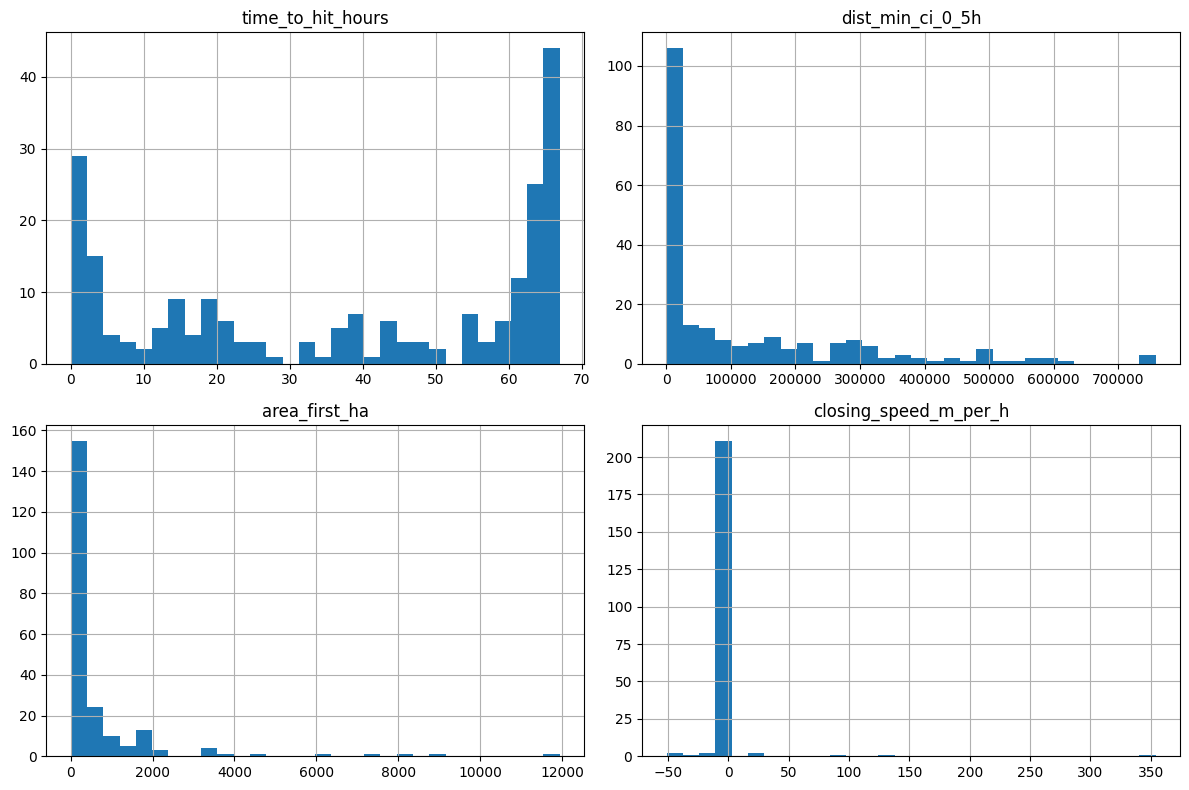

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

train["time_to_hit_hours"].hist(ax=axes[0, 0], bins=30)
axes[0, 0].set_title("time_to_hit_hours")

train["dist_min_ci_0_5h"].hist(ax=axes[0, 1], bins=30)
axes[0, 1].set_title("dist_min_ci_0_5h")

train["area_first_ha"].hist(ax=axes[1, 0], bins=30)
axes[1, 0].set_title("area_first_ha")

train["closing_speed_m_per_h"].hist(ax=axes[1, 1], bins=30)
axes[1, 1].set_title("closing_speed_m_per_h")

plt.tight_layout()

## Takeaways

- The dataset is small, clean, and fully numeric, which favors strong tabular baselines.
- Censoring is heavy, especially for later horizons, so horizon labels must be created carefully.
- Low temporal resolution is common and appears materially associated with lower event rate.
- The strongest early drift signals are in area, growth, and motion features, which are worth tracking during validation.

In [10]:
import warnings; warnings.filterwarnings("ignore")

import numpy as np
import scipy.stats as stats
from scipy.stats import pointbiserialr, spearmanr, gaussian_kde
import seaborn as sns
from sklearn.metrics import roc_auc_score
from lifelines import KaplanMeierFitter, CoxPHFitter
from lifelines.statistics import logrank_test
from lifelines.utils import concordance_index

np.random.seed(42)
category_map = meta.set_index("column")["category"].to_dict()
print("Extended imports ready.")

Extended imports ready.


## 6. Feature Distribution and Zero-Inflation

In [11]:
dist_rows = []
for col in feature_cols:
    s = train[col]
    dist_rows.append({
        "feature": col,
        "category": category_map.get(col, ""),
        "mean": round(s.mean(), 4),
        "std": round(s.std(), 4),
        "skewness": round(stats.skew(s), 4),
        "kurtosis": round(stats.kurtosis(s), 4),
        "zero_fraction": round((s == 0).mean(), 4),
        "pct_1": round(s.quantile(0.01), 4),
        "pct_99": round(s.quantile(0.99), 4),
    })

dist_df = pd.DataFrame(dist_rows).set_index("feature")
display(dist_df.sort_values("skewness", key=abs, ascending=False))

transform_candidates = dist_df[dist_df["skewness"].abs() > 2].index.tolist()
zero_inflated = dist_df[dist_df["zero_fraction"] > 0.30].index.tolist()
print(f"\nTRANSFORM CANDIDATES (|skew|>2):  {transform_candidates}")
print(f"ZERO-INFLATED (zero_frac>0.30):   {zero_inflated}")

,category,mean,std,skewness,kurtosis,zero_fraction,pct_1,pct_99
feature,,,,,,,,
dist_slope_ci_0_5h,distance,-3.0309,41.5112,-11.8992,154.8049,0.7647,-74.0531,39.3654
area_growth_rel_0_5h,growth,0.1789,1.3020,11.8704,154.6537,0.8869,0.0000,3.2903
relative_growth_0_5h,growth,0.1789,1.3020,11.8704,154.6537,0.8869,0.0000,3.2903
dist_std_ci_0_5h,distance,8.0790,63.1844,11.5106,144.6526,0.9140,0.0000,166.7050
area_growth_abs_0_5h,growth,26.3324,187.4370,11.1549,139.3472,0.8869,0.0000,562.2635
dist_change_ci_0_5h,distance,-10.2870,128.6527,-11.1113,138.4315,0.9186,-372.9697,85.3347
projected_advance_m,distance,10.2870,128.6527,11.1113,138.4315,0.9186,-85.3347,372.9697
closing_speed_abs_m_per_h,distance,3.6611,26.6904,11.0764,136.0528,0.9186,0.0000,85.4176
closing_speed_m_per_h,distance,2.0214,26.8652,10.9194,135.1865,0.9186,-29.5438,80.2053



TRANSFORM CANDIDATES (|skew|>2):  ['num_perimeters_0_5h', 'area_first_ha', 'area_growth_abs_0_5h', 'area_growth_rel_0_5h', 'area_growth_rate_ha_per_h', 'log1p_growth', 'log_area_ratio_0_5h', 'relative_growth_0_5h', 'radial_growth_m', 'radial_growth_rate_m_per_h', 'centroid_displacement_m', 'centroid_speed_m_per_h', 'spread_bearing_deg', 'spread_bearing_cos', 'dist_std_ci_0_5h', 'dist_change_ci_0_5h', 'dist_slope_ci_0_5h', 'closing_speed_m_per_h', 'closing_speed_abs_m_per_h', 'projected_advance_m', 'dist_accel_m_per_h2', 'dist_fit_r2_0_5h', 'cross_track_component', 'along_track_speed']
ZERO-INFLATED (zero_frac>0.30):   ['dt_first_last_0_5h', 'area_growth_abs_0_5h', 'area_growth_rel_0_5h', 'area_growth_rate_ha_per_h', 'log1p_growth', 'log_area_ratio_0_5h', 'relative_growth_0_5h', 'radial_growth_m', 'radial_growth_rate_m_per_h', 'centroid_displacement_m', 'centroid_speed_m_per_h', 'spread_bearing_deg', 'spread_bearing_sin', 'dist_std_ci_0_5h', 'dist_change_ci_0_5h', 'dist_slope_ci_0_5h',

In [12]:
nzv_rows = []
for col in feature_cols:
    s = train[col]
    nzv_rows.append({
        "feature": col,
        "std": round(s.std(), 6),
        "n_unique": s.nunique(),
        "is_binary_or_nzv": int(s.nunique() <= 2 or s.std() < 1e-8),
    })
nzv_df = pd.DataFrame(nzv_rows).set_index("feature").sort_values("n_unique")
display(nzv_df[nzv_df["n_unique"] <= 5])
print("Binary/low-cardinality features — treat as categorical in linear models.")

,std,n_unique,is_binary_or_nzv
feature,,,
low_temporal_resolution_0_5h,0.445739,2,1


Binary/low-cardinality features — treat as categorical in linear models.


In [13]:
outlier_rows = []
for col in feature_cols:
    s = train[col]
    q1, q3 = s.quantile(0.25), s.quantile(0.75)
    iqr = q3 - q1
    lower, upper = q1 - 3 * iqr, q3 + 3 * iqr
    n_out = int(((s < lower) | (s > upper)).sum())
    outlier_rows.append({
        "feature": col,
        "n_outliers": n_out,
        "pct_outliers": round(n_out / len(s), 4),
        "max_val": round(s.max(), 2),
        "upper_bound_3iqr": round(upper, 2),
    })
outlier_df = (
    pd.DataFrame(outlier_rows)
    .set_index("feature")
    .sort_values("n_outliers", ascending=False)
)
display(outlier_df[outlier_df["n_outliers"] > 0])
outlier_heavy = outlier_df[outlier_df["pct_outliers"] >= 0.05].index.tolist()
print(f"\nOUTLIER-HEAVY (>=5% rows at 3xIQR):  {outlier_heavy}")

,n_outliers,pct_outliers,max_val,upper_bound_3iqr
feature,,,,
alignment_cos,61,0.2760,0.99,0.00
dist_slope_ci_0_5h,52,0.2353,69.99,0.00
alignment_abs,48,0.2172,1.00,0.29
dist_accel_m_per_h2,35,0.1584,17.51,0.00
along_track_speed,25,0.1131,383.10,0.00
cross_track_component,25,0.1131,277.11,0.00
area_growth_rel_0_5h,25,0.1131,17.89,0.00
area_growth_abs_0_5h,25,0.1131,2508.04,0.00
log_area_ratio_0_5h,25,0.1131,2.94,0.00



OUTLIER-HEAVY (>=5% rows at 3xIQR):  ['alignment_cos', 'dist_slope_ci_0_5h', 'alignment_abs', 'dist_accel_m_per_h2', 'along_track_speed', 'cross_track_component', 'area_growth_rel_0_5h', 'area_growth_abs_0_5h', 'log_area_ratio_0_5h', 'area_growth_rate_ha_per_h', 'centroid_speed_m_per_h', 'spread_bearing_deg', 'spread_bearing_sin', 'spread_bearing_cos', 'centroid_displacement_m', 'radial_growth_rate_m_per_h', 'radial_growth_m', 'relative_growth_0_5h', 'log1p_growth', 'num_perimeters_0_5h', 'dist_fit_r2_0_5h', 'dist_std_ci_0_5h', 'closing_speed_abs_m_per_h', 'dist_change_ci_0_5h', 'closing_speed_m_per_h', 'projected_advance_m', 'area_first_ha']


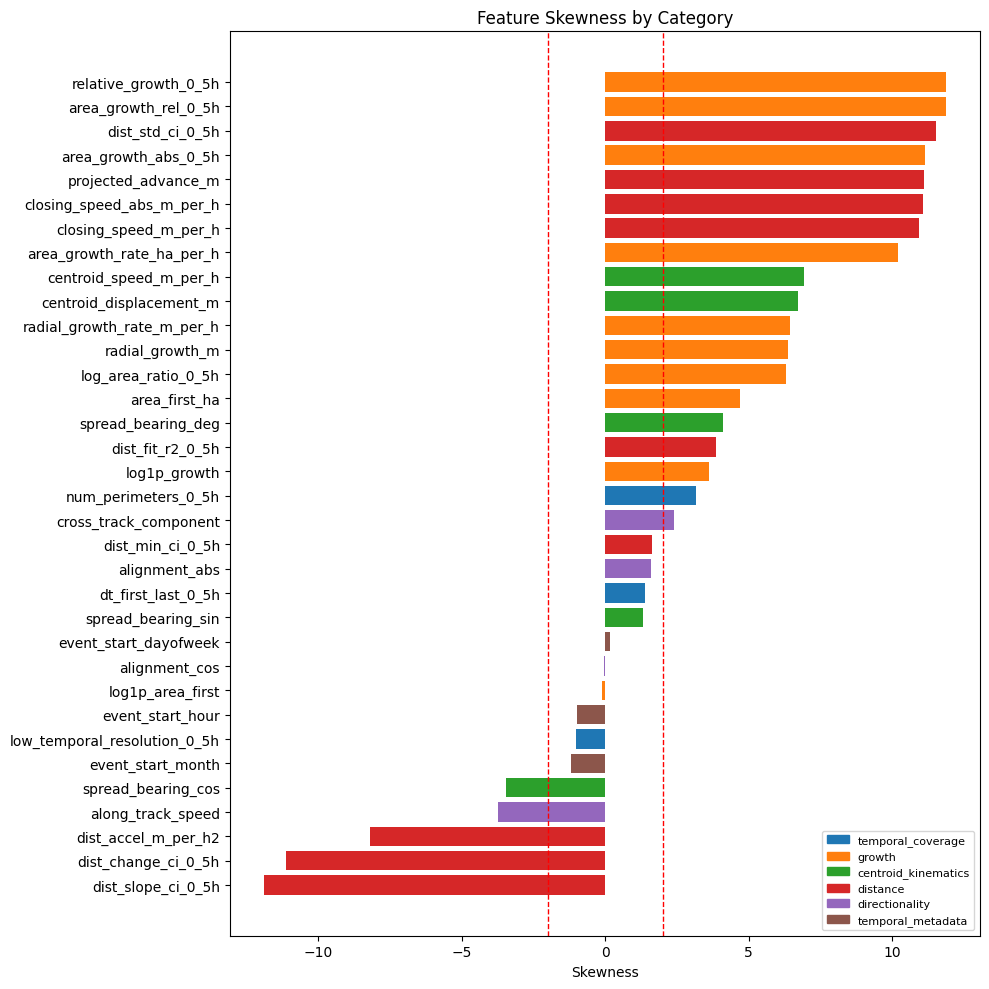

In [14]:
cat_list = dist_df["category"].unique().tolist()
palette = plt.cm.tab10.colors
cat_colors = {c: palette[i % len(palette)] for i, c in enumerate(cat_list)}

skew_sorted = dist_df["skewness"].sort_values()
bar_colors = [cat_colors.get(dist_df.loc[f, "category"], "gray") for f in skew_sorted.index]

fig, ax = plt.subplots(figsize=(10, 10))
ax.barh(skew_sorted.index, skew_sorted.values, color=bar_colors)
ax.axvline(2,  color="red", ls="--", lw=1, label="|skew| = 2 threshold")
ax.axvline(-2, color="red", ls="--", lw=1)
ax.set_xlabel("Skewness")
ax.set_title("Feature Skewness by Category")
handles = [plt.Rectangle((0, 0), 1, 1, color=cat_colors[c]) for c in cat_list]
ax.legend(handles, cat_list, loc="lower right", fontsize=8)
plt.tight_layout()
plt.show()

## 7. Collinearity Analysis

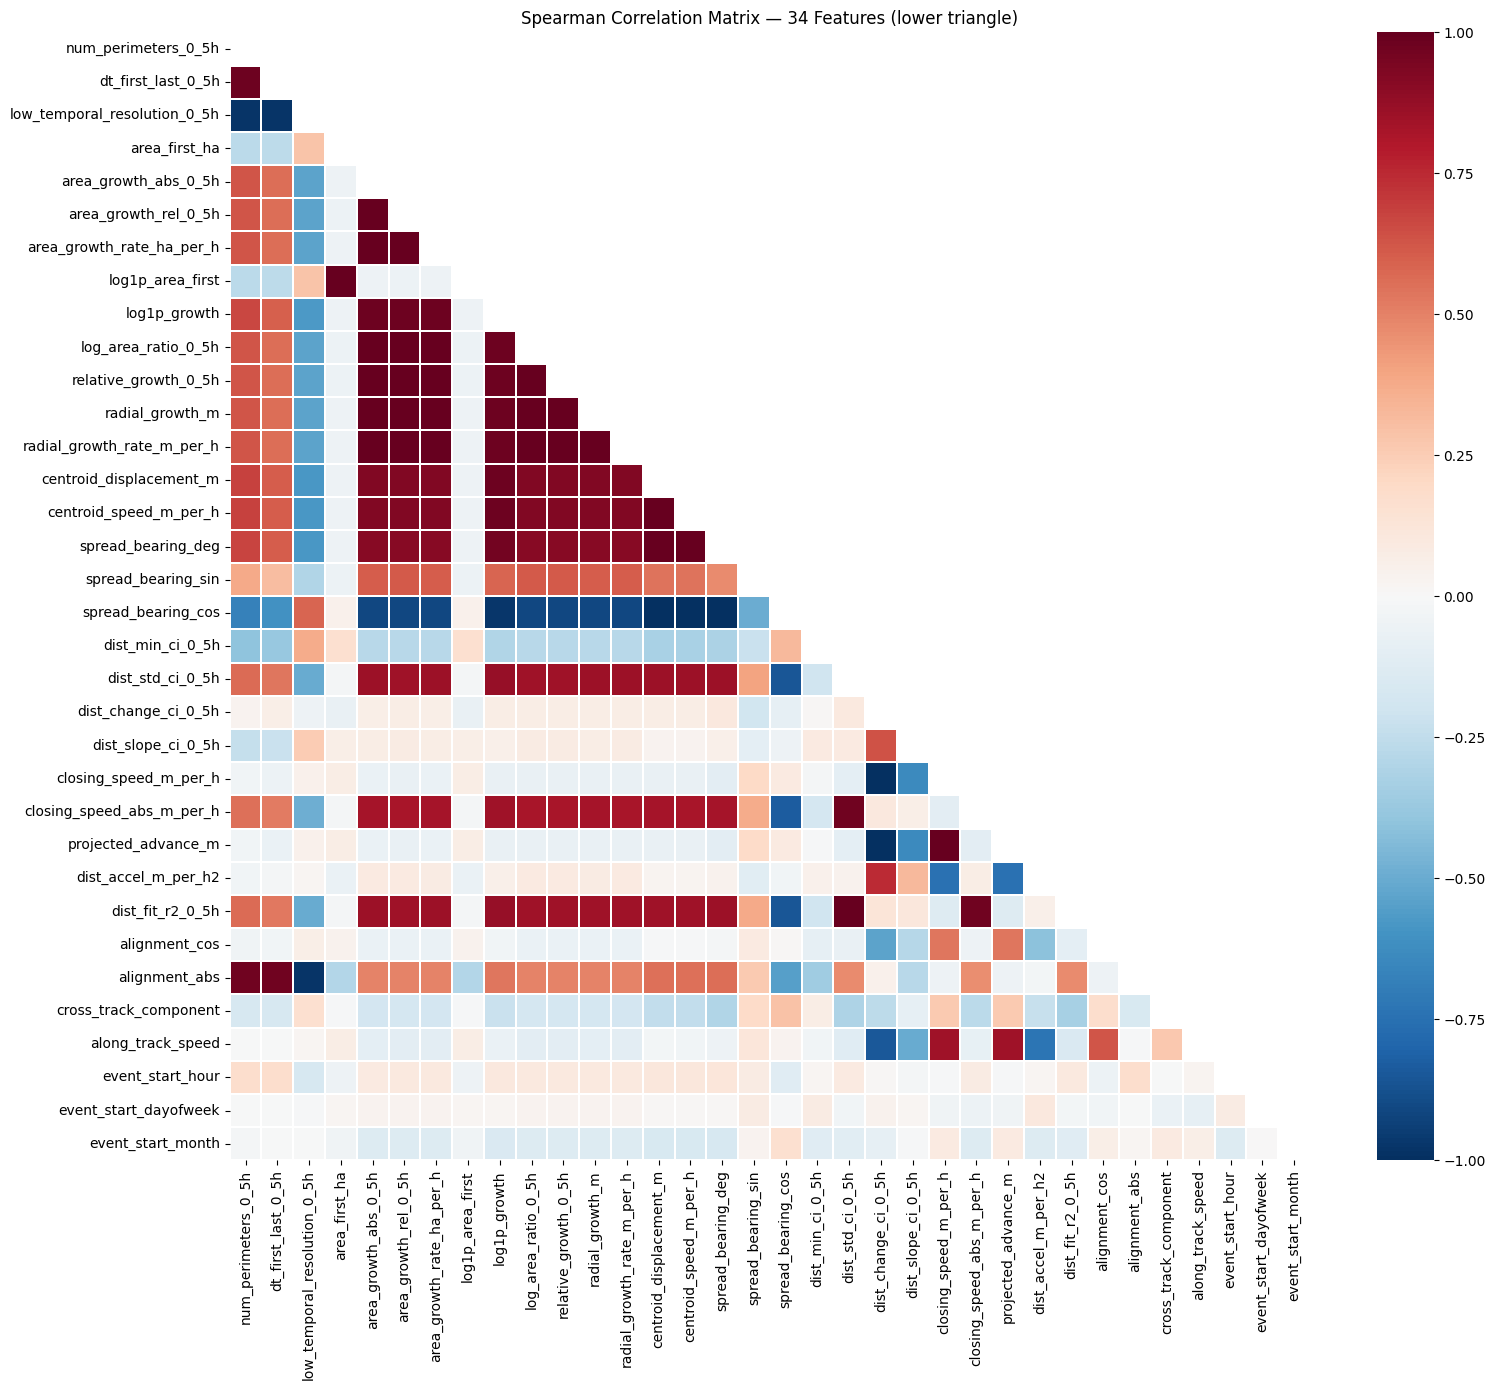

In [15]:
corr_matrix = train[feature_cols].corr(method="spearman")

fig, ax = plt.subplots(figsize=(16, 14))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix,
    mask=mask,
    cmap="RdBu_r",
    center=0,
    vmin=-1,
    vmax=1,
    linewidths=0.3,
    ax=ax,
    annot=False,
)
ax.set_title("Spearman Correlation Matrix — 34 Features (lower triangle)")
plt.tight_layout()
plt.show()

In [16]:
threshold = 0.85
cols_list = corr_matrix.columns.tolist()
high_corr_pairs = []
for i in range(len(cols_list)):
    for j in range(i + 1, len(cols_list)):
        rho = corr_matrix.iloc[i, j]
        if abs(rho) > threshold:
            high_corr_pairs.append({
                "feature_a": cols_list[i],
                "feature_b": cols_list[j],
                "spearman_rho": round(rho, 4),
                "category_a": category_map.get(cols_list[i], ""),
                "category_b": category_map.get(cols_list[j], ""),
            })

high_corr_df = pd.DataFrame(high_corr_pairs).sort_values(
    "spearman_rho", key=abs, ascending=False
)
print(f"High-collinearity pairs (|rho| > {threshold}): {len(high_corr_df)}")
display(high_corr_df)

High-collinearity pairs (|rho| > 0.85): 98


,feature_a,feature_b,spearman_rho,category_a,category_b
23,area_growth_rel_0_5h,relative_growth_0_5h,1.0000,growth,growth
6,area_first_ha,log1p_area_first,1.0000,growth,growth
22,area_growth_rel_0_5h,log_area_ratio_0_5h,1.0000,growth,growth
95,dist_change_ci_0_5h,projected_advance_m,-1.0000,distance,distance
96,closing_speed_m_per_h,projected_advance_m,1.0000,distance,distance
...,...,...,...,...,...
73,radial_growth_m,dist_fit_r2_0_5h,0.8515,growth,distance
83,centroid_displacement_m,dist_fit_r2_0_5h,0.8511,centroid_kinematics,distance
30,area_growth_rel_0_5h,dist_std_ci_0_5h,0.8502,growth,distance
59,log_area_ratio_0_5h,dist_std_ci_0_5h,0.8502,growth,distance


In [17]:
groups = []
for _, row in high_corr_df.iterrows():
    a, b = row["feature_a"], row["feature_b"]
    placed = False
    for g in groups:
        if a in g or b in g:
            g.update([a, b])
            placed = True
            break
    if not placed:
        groups.append({a, b})

print("Collinearity Groups (|rho| > 0.85):")
for i, g in enumerate(sorted(groups, key=len, reverse=True)):
    print(f"  Group {i + 1} ({len(g)} features): {sorted(g)}")
print("\nNote: Trees (LightGBM/CatBoost) are robust to collinearity — no action needed.")
print("      Cox PH and elastic-net: keep one member per group.")

Collinearity Groups (|rho| > 0.85):
  Group 1 (14 features): ['area_growth_abs_0_5h', 'area_growth_rate_ha_per_h', 'area_growth_rel_0_5h', 'centroid_displacement_m', 'centroid_speed_m_per_h', 'dist_fit_r2_0_5h', 'dist_std_ci_0_5h', 'log1p_growth', 'log_area_ratio_0_5h', 'radial_growth_m', 'radial_growth_rate_m_per_h', 'relative_growth_0_5h', 'spread_bearing_cos', 'spread_bearing_deg']
  Group 2 (4 features): ['area_growth_abs_0_5h', 'area_growth_rate_ha_per_h', 'radial_growth_m', 'radial_growth_rate_m_per_h']
  Group 3 (4 features): ['centroid_displacement_m', 'centroid_speed_m_per_h', 'spread_bearing_cos', 'spread_bearing_deg']
  Group 4 (4 features): ['alignment_abs', 'dt_first_last_0_5h', 'low_temporal_resolution_0_5h', 'num_perimeters_0_5h']
  Group 5 (3 features): ['closing_speed_m_per_h', 'dist_change_ci_0_5h', 'projected_advance_m']
  Group 6 (3 features): ['closing_speed_abs_m_per_h', 'dist_fit_r2_0_5h', 'dist_std_ci_0_5h']
  Group 7 (2 features): ['area_first_ha', 'log1p_area_

## 8. Univariate Feature-Target Relationships

In [18]:
cox_results = []
for col in feature_cols:
    success = False
    for penalizer in [0.1, 0.5]:
        try:
            df_cox = train[[col, "time_to_hit_hours", "event"]].copy()
            df_cox[col] = (df_cox[col] - df_cox[col].mean()) / (df_cox[col].std() + 1e-9)
            cph = CoxPHFitter(penalizer=penalizer)
            cph.fit(df_cox, duration_col="time_to_hit_hours", event_col="event",
                    show_progress=False)
            s = cph.summary
            cox_results.append({
                "feature": col,
                "hazard_ratio": round(float(np.exp(s["coef"].iloc[0])), 4),
                "cox_p_value": round(float(s["p"].iloc[0]), 4),
                "cox_concordance": round(cph.concordance_index_, 4),
                "penalizer_used": penalizer,
            })
            success = True
            break
        except Exception:
            pass
    if not success:
        cox_results.append({
            "feature": col, "hazard_ratio": None,
            "cox_p_value": None, "cox_concordance": None, "penalizer_used": None,
        })

cox_df = pd.DataFrame(cox_results).set_index("feature")
n_ok = cox_df["cox_concordance"].notna().sum()
print(f"Cox PH fitted for {n_ok}/{len(feature_cols)} features.")

Cox PH fitted for 34/34 features.


In [19]:
pb_results = []
for col in feature_cols:
    r, p = pointbiserialr(train[col], train["event"])
    pb_results.append({"feature": col, "pb_r": round(r, 4), "pb_p": round(p, 4)})

pb_df = pd.DataFrame(pb_results).set_index("feature")

In [20]:
events_only = train[train["event"] == 1]
sp_results = []
for col in feature_cols:
    rho, p = spearmanr(events_only[col], events_only["time_to_hit_hours"])
    sp_results.append({
        "feature": col,
        "spearman_rho_tte": round(rho, 4),
        "spearman_tte_p": round(p, 4),
    })

sp_df = pd.DataFrame(sp_results).set_index("feature")
print(f"Spearman (feature vs time_to_hit_hours) computed on {len(events_only)} events only.")

Spearman (feature vs time_to_hit_hours) computed on 69 events only.


In [21]:
ci_results = []
for col in feature_cols:
    try:
        ci = concordance_index(train["time_to_hit_hours"], -train[col], train["event"])
        ci = max(ci, 1 - ci)
    except Exception:
        ci = None
    ci_results.append({
        "feature": col,
        "univariate_cindex": round(ci, 4) if ci is not None else None,
    })

ci_df = pd.DataFrame(ci_results).set_index("feature")

In [22]:
univariate_summary = (
    ci_df
    .join(cox_df[["hazard_ratio", "cox_p_value", "cox_concordance"]], how="left")
    .join(pb_df[["pb_r", "pb_p"]], how="left")
    .join(sp_df[["spearman_rho_tte"]], how="left")
)
univariate_summary["category"] = univariate_summary.index.map(category_map)
univariate_summary = univariate_summary.sort_values("univariate_cindex", ascending=False)
display(univariate_summary.round(4))

sig_cox = univariate_summary[univariate_summary["cox_p_value"] < 0.05].index.tolist()
low_signal = univariate_summary[
    (univariate_summary["cox_p_value"] > 0.3)
    & (univariate_summary["univariate_cindex"] < 0.55)
].index.tolist()
print(f"\nCox p < 0.05:                      {sig_cox}")
print(f"Low signal (Cox p>0.3, CI<0.55):   {low_signal}")

,univariate_cindex,hazard_ratio,cox_p_value,cox_concordance,pb_r,pb_p,spearman_rho_tte,category
feature,,,,,,,,
dist_min_ci_0_5h,0.9095,0.3818,0.0000,0.9095,-0.4814,0.0000,0.0849,distance
num_perimeters_0_5h,0.7177,1.6165,0.0000,0.7177,0.3705,0.0000,-0.6177,temporal_coverage
dt_first_last_0_5h,0.7035,1.7227,0.0000,0.7035,0.3530,0.0000,-0.5836,temporal_coverage
alignment_abs,0.6992,1.6259,0.0000,0.6992,0.3491,0.0000,-0.5374,directionality
low_temporal_resolution_0_5h,0.6947,0.5559,0.0000,0.6947,-0.3791,0.0000,0.5958,temporal_coverage
centroid_displacement_m,0.6192,1.3081,0.0002,0.6192,0.2080,0.0019,-0.4115,centroid_kinematics
centroid_speed_m_per_h,0.6191,1.3019,0.0001,0.6191,0.2093,0.0018,-0.4170,centroid_kinematics
spread_bearing_cos,0.6186,0.6357,0.0000,0.6186,-0.3232,0.0000,0.4097,centroid_kinematics
spread_bearing_deg,0.6173,1.4153,0.0000,0.6173,0.2810,0.0000,-0.4019,centroid_kinematics



Cox p < 0.05:                      ['dist_min_ci_0_5h', 'num_perimeters_0_5h', 'dt_first_last_0_5h', 'alignment_abs', 'low_temporal_resolution_0_5h', 'centroid_displacement_m', 'centroid_speed_m_per_h', 'spread_bearing_cos', 'spread_bearing_deg', 'log1p_growth', 'area_growth_rate_ha_per_h', 'area_growth_abs_0_5h', 'radial_growth_rate_m_per_h', 'radial_growth_m', 'relative_growth_0_5h', 'log_area_ratio_0_5h', 'area_growth_rel_0_5h', 'dist_slope_ci_0_5h', 'dist_std_ci_0_5h', 'dist_fit_r2_0_5h', 'spread_bearing_sin', 'log1p_area_first', 'area_first_ha', 'closing_speed_abs_m_per_h', 'closing_speed_m_per_h', 'projected_advance_m', 'dist_change_ci_0_5h']
Low signal (Cox p>0.3, CI<0.55):   ['event_start_hour', 'along_track_speed']


## 9. Kaplan-Meier Survival Curves

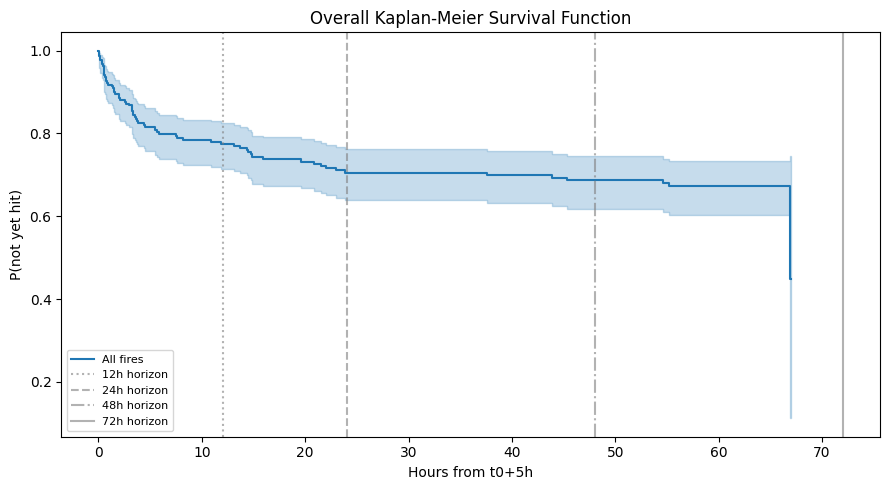

In [23]:
kmf = KaplanMeierFitter()
kmf.fit(train["time_to_hit_hours"], event_observed=train["event"], label="All fires")

fig, ax = plt.subplots(figsize=(9, 5))
kmf.plot_survival_function(ax=ax, ci_show=True)
for h, ls in [(12, ":"), (24, "--"), (48, "-."), (72, "-")]:
    ax.axvline(h, ls=ls, color="gray", alpha=0.6, label=f"{h}h horizon")
ax.set_title("Overall Kaplan-Meier Survival Function")
ax.set_xlabel("Hours from t0+5h")
ax.set_ylabel("P(not yet hit)")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

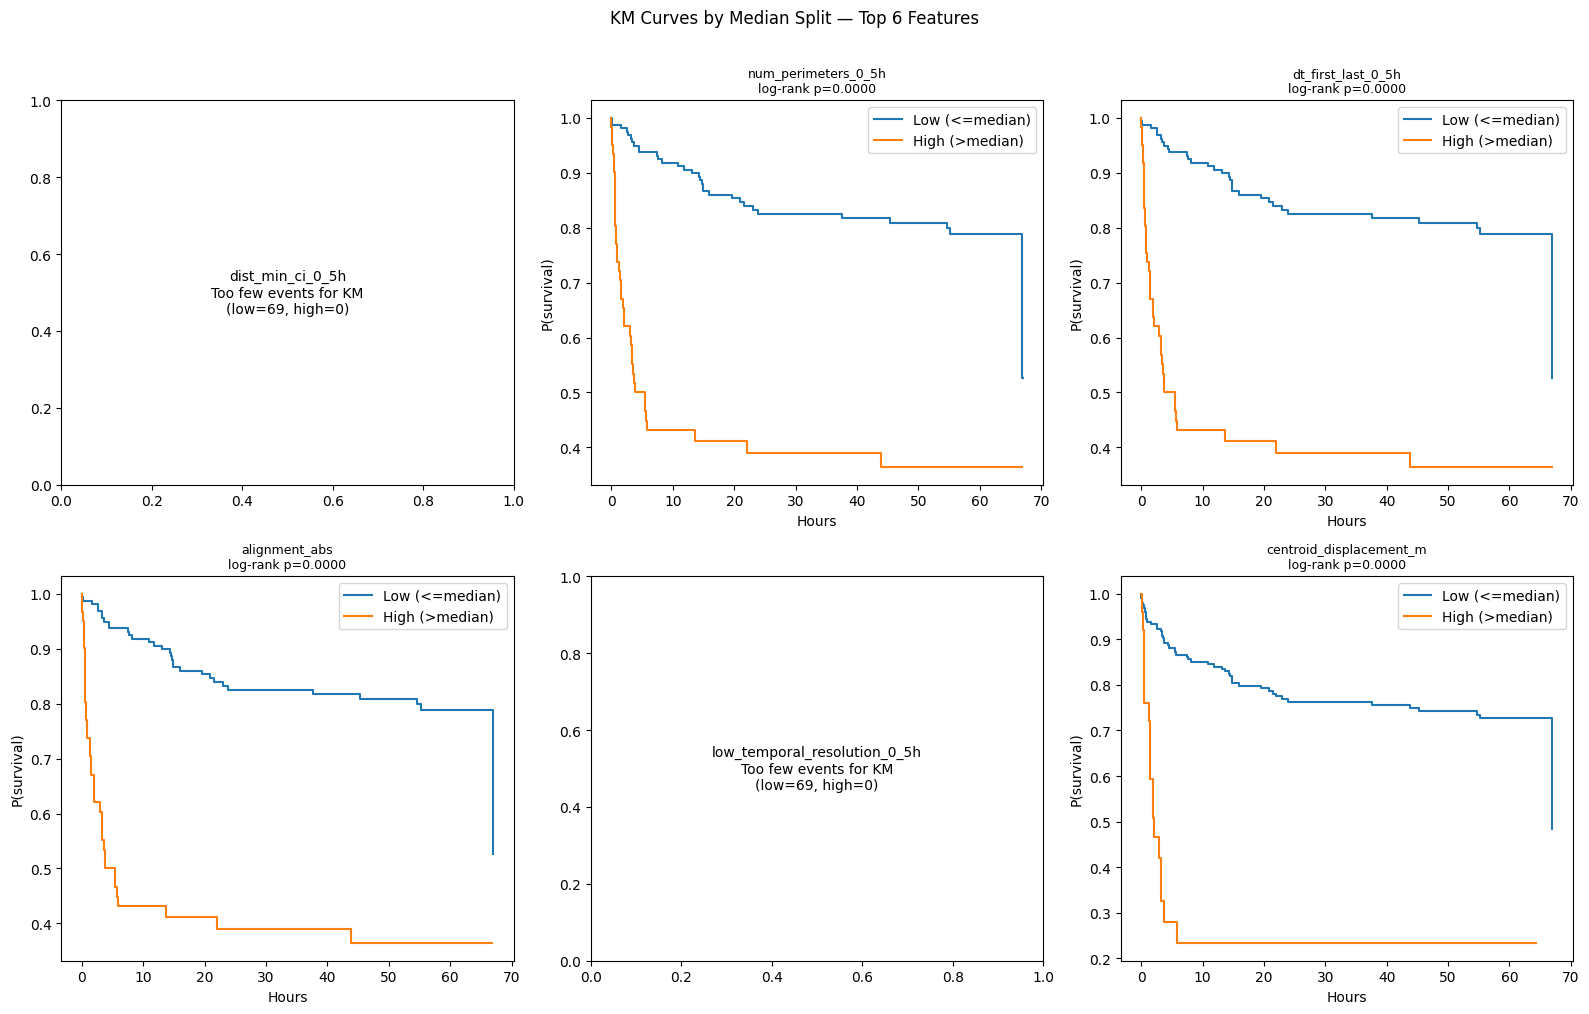

Non-proportional hazard warnings (KM curves cross): []


In [25]:
top6_features = (
    univariate_summary.dropna(subset=["univariate_cindex"]).head(6).index.tolist()
)
crossing_features = []

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(top6_features):
    ax = axes[i]
    median_val = train[col].median()
    low_g = train[train[col] <= median_val]
    high_g = train[train[col] > median_val]

    n_ev_low = int(low_g["event"].sum())
    n_ev_high = int(high_g["event"].sum())
    if n_ev_low < 10 or n_ev_high < 10:
        ax.text(0.5, 0.5,
                f"{col}\nToo few events for KM\n(low={n_ev_low}, high={n_ev_high})",
                ha="center", va="center", transform=ax.transAxes)
        continue

    lr = logrank_test(
        low_g["time_to_hit_hours"], high_g["time_to_hit_hours"],
        event_observed_A=low_g["event"], event_observed_B=high_g["event"],
    )

    kmf_low = KaplanMeierFitter()
    kmf_high = KaplanMeierFitter()
    kmf_low.fit(low_g["time_to_hit_hours"], event_observed=low_g["event"],
                label="Low (<=median)")
    kmf_high.fit(high_g["time_to_hit_hours"], event_observed=high_g["event"],
                 label="High (>median)")

    kmf_low.plot_survival_function(ax=ax, ci_show=False)
    kmf_high.plot_survival_function(ax=ax, ci_show=False)
    ax.set_title(f"{col}\nlog-rank p={lr.p_value:.4f}", fontsize=9)
    ax.set_xlabel("Hours")
    ax.set_ylabel("P(survival)")

    low_sf  = kmf_low.survival_function_.iloc[:, 0]
    high_sf = kmf_high.survival_function_.iloc[:, 0]
    common_idx = low_sf.index.intersection(high_sf.index)
    if len(common_idx) > 2:
        diff = low_sf.loc[common_idx].values - high_sf.loc[common_idx].values
        if diff[0] * diff[-1] < 0:
            crossing_features.append(col)

plt.suptitle("KM Curves by Median Split — Top 6 Features", y=1.01)
plt.tight_layout()
plt.show()
print(f"Non-proportional hazard warnings (KM curves cross): {crossing_features}")

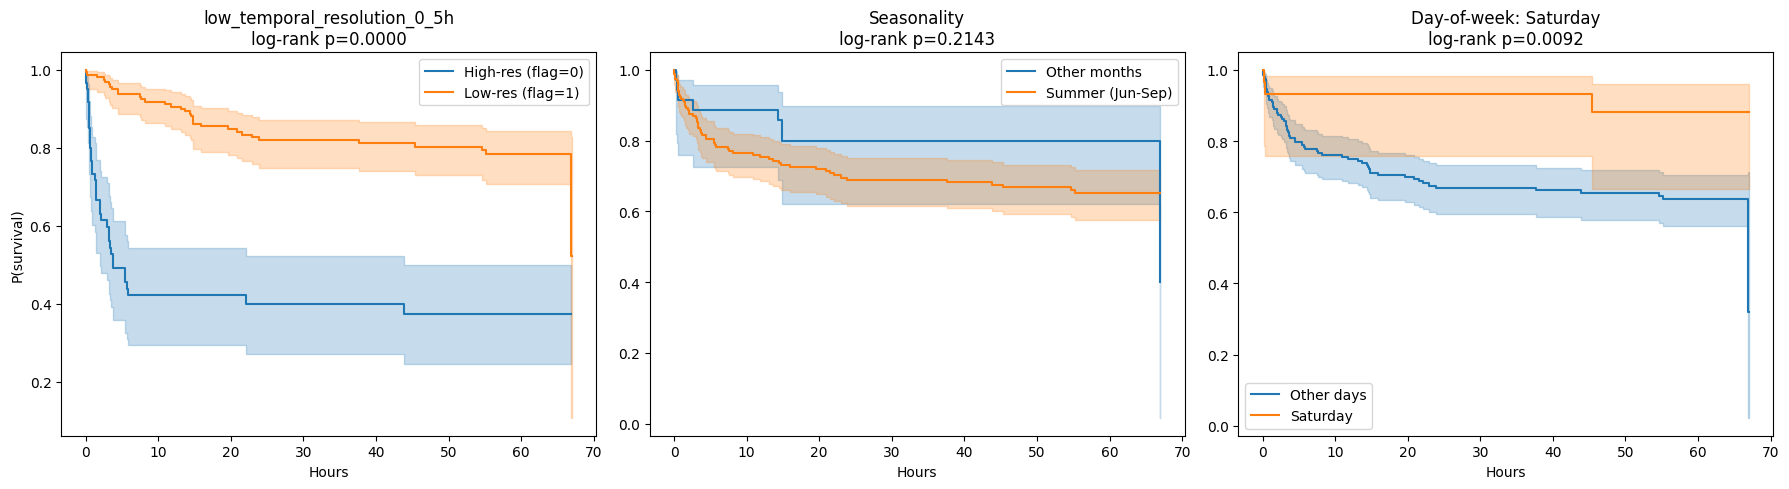

In [26]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. low_temporal_resolution_0_5h
ax = axes[0]
for val, label in [(0, "High-res (flag=0)"), (1, "Low-res (flag=1)")]:
    sub = train[train["low_temporal_resolution_0_5h"] == val]
    KaplanMeierFitter().fit(
        sub["time_to_hit_hours"], event_observed=sub["event"], label=label
    ).plot_survival_function(ax=ax, ci_show=True)
lr1 = logrank_test(
    train.loc[train["low_temporal_resolution_0_5h"] == 0, "time_to_hit_hours"],
    train.loc[train["low_temporal_resolution_0_5h"] == 1, "time_to_hit_hours"],
    event_observed_A=train.loc[train["low_temporal_resolution_0_5h"] == 0, "event"],
    event_observed_B=train.loc[train["low_temporal_resolution_0_5h"] == 1, "event"],
)
ax.set_title(f"low_temporal_resolution_0_5h\nlog-rank p={lr1.p_value:.4f}")
ax.set_xlabel("Hours"); ax.set_ylabel("P(survival)")

# 2. Seasonality: summer (Jun-Sep) vs other
ax = axes[1]
train["_summer"] = train["event_start_month"].isin([6, 7, 8, 9]).map(
    {True: "Summer (Jun-Sep)", False: "Other months"}
)
for label, sub in train.groupby("_summer"):
    KaplanMeierFitter().fit(
        sub["time_to_hit_hours"], event_observed=sub["event"], label=label
    ).plot_survival_function(ax=ax, ci_show=True)
vals = train["_summer"].unique().tolist()
lr2 = logrank_test(
    train.loc[train["_summer"] == vals[0], "time_to_hit_hours"],
    train.loc[train["_summer"] == vals[1], "time_to_hit_hours"],
    event_observed_A=train.loc[train["_summer"] == vals[0], "event"],
    event_observed_B=train.loc[train["_summer"] == vals[1], "event"],
)
ax.set_title(f"Seasonality\nlog-rank p={lr2.p_value:.4f}")
ax.set_xlabel("Hours")

# 3. Day-of-week: Saturday vs other
ax = axes[2]
train["_sat"] = (train["event_start_dayofweek"] == 5).map(
    {True: "Saturday", False: "Other days"}
)
for label, sub in train.groupby("_sat"):
    KaplanMeierFitter().fit(
        sub["time_to_hit_hours"], event_observed=sub["event"], label=label
    ).plot_survival_function(ax=ax, ci_show=True)
vsat = train["_sat"].unique().tolist()
lr3 = logrank_test(
    train.loc[train["_sat"] == vsat[0], "time_to_hit_hours"],
    train.loc[train["_sat"] == vsat[1], "time_to_hit_hours"],
    event_observed_A=train.loc[train["_sat"] == vsat[0], "event"],
    event_observed_B=train.loc[train["_sat"] == vsat[1], "event"],
)
ax.set_title(f"Day-of-week: Saturday\nlog-rank p={lr3.p_value:.4f}")
ax.set_xlabel("Hours")

train.drop(columns=["_summer", "_sat"], inplace=True)
plt.tight_layout()
plt.show()

## 10. Horizon-Specific Label Analysis

In [27]:
horizon_label_stats = []
for H in [12, 24, 48, 72]:
    mask_pos = (train["event"] == 1) & (train["time_to_hit_hours"] <= H)
    mask_neg = train["time_to_hit_hours"] > H
    mask_excl = (train["event"] == 0) & (train["time_to_hit_hours"] <= H)
    n_pos, n_neg, n_excl = int(mask_pos.sum()), int(mask_neg.sum()), int(mask_excl.sum())
    n_eff = n_pos + n_neg
    horizon_label_stats.append({
        "horizon_H": H,
        "n_positive": n_pos,
        "n_negative": n_neg,
        "n_excluded_censored": n_excl,
        "n_effective": n_eff,
        "positive_rate_eff": round(n_pos / n_eff, 4) if n_eff > 0 else None,
        "exclusion_rate": round(n_excl / len(train), 4),
    })

horizon_eff_df = pd.DataFrame(horizon_label_stats)
display(horizon_eff_df)
print("\nKey: 72h has very few effective rows after censor exclusion.")
print("Survival models use all 221 rows; a dedicated 72h classifier is severely data-limited.")

,horizon_H,n_positive,n_negative,n_excluded_censored,n_effective,positive_rate_eff,exclusion_rate
0,12,49,166,6,215,0.2279,0.0271
1,24,63,133,25,196,0.3214,0.1131
2,48,66,100,55,166,0.3976,0.2489
3,72,69,0,152,69,1.0000,0.6878



Key: 72h has very few effective rows after censor exclusion.
Survival models use all 221 rows; a dedicated 72h classifier is severely data-limited.


In [28]:
horizon_auc_rows = []
for H in [12, 24, 48, 72]:
    mask_pos = (train["event"] == 1) & (train["time_to_hit_hours"] <= H)
    mask_neg = train["time_to_hit_hours"] > H
    valid = mask_pos | mask_neg
    subset = train[valid]
    y = mask_pos[valid].astype(int)
    for col in feature_cols:
        try:
            auc = roc_auc_score(y, subset[col])
            auc = max(auc, 1 - auc)
        except Exception:
            auc = None
        horizon_auc_rows.append({"horizon": H, "feature": col, "auc": auc})

horizon_auc_pivot = (
    pd.DataFrame(horizon_auc_rows)
    .pivot(index="feature", columns="horizon", values="auc")
    .rename(columns={h: f"AUC_{h}h" for h in [12, 24, 48, 72]})
)
horizon_auc_pivot["mean_AUC"] = horizon_auc_pivot.mean(axis=1)
horizon_auc_pivot = horizon_auc_pivot.sort_values("mean_AUC", ascending=False)
display(horizon_auc_pivot.round(4).head(15))
print("\nTop 15 features by mean direction-agnostic AUC across all 4 horizons.")

horizon,AUC_12h,AUC_24h,AUC_48h,AUC_72h,mean_AUC
feature,,,,,
dist_min_ci_0_5h,0.9352,0.9754,0.9806,NaN,0.9637
num_perimeters_0_5h,0.7983,0.7306,0.7337,NaN,0.7542
dt_first_last_0_5h,0.7859,0.7208,0.7277,NaN,0.7448
low_temporal_resolution_0_5h,0.7807,0.7101,0.7177,NaN,0.7362
alignment_abs,0.7761,0.7083,0.7173,NaN,0.7339
spread_bearing_cos,0.6738,0.6332,0.6280,NaN,0.6450
spread_bearing_deg,0.6727,0.6321,0.6282,NaN,0.6443
centroid_displacement_m,0.6721,0.6313,0.6252,NaN,0.6429
centroid_speed_m_per_h,0.6711,0.6304,0.6245,NaN,0.6420



Top 15 features by mean direction-agnostic AUC across all 4 horizons.


## 11. Feature vs. Event Distributions (Boxplots)

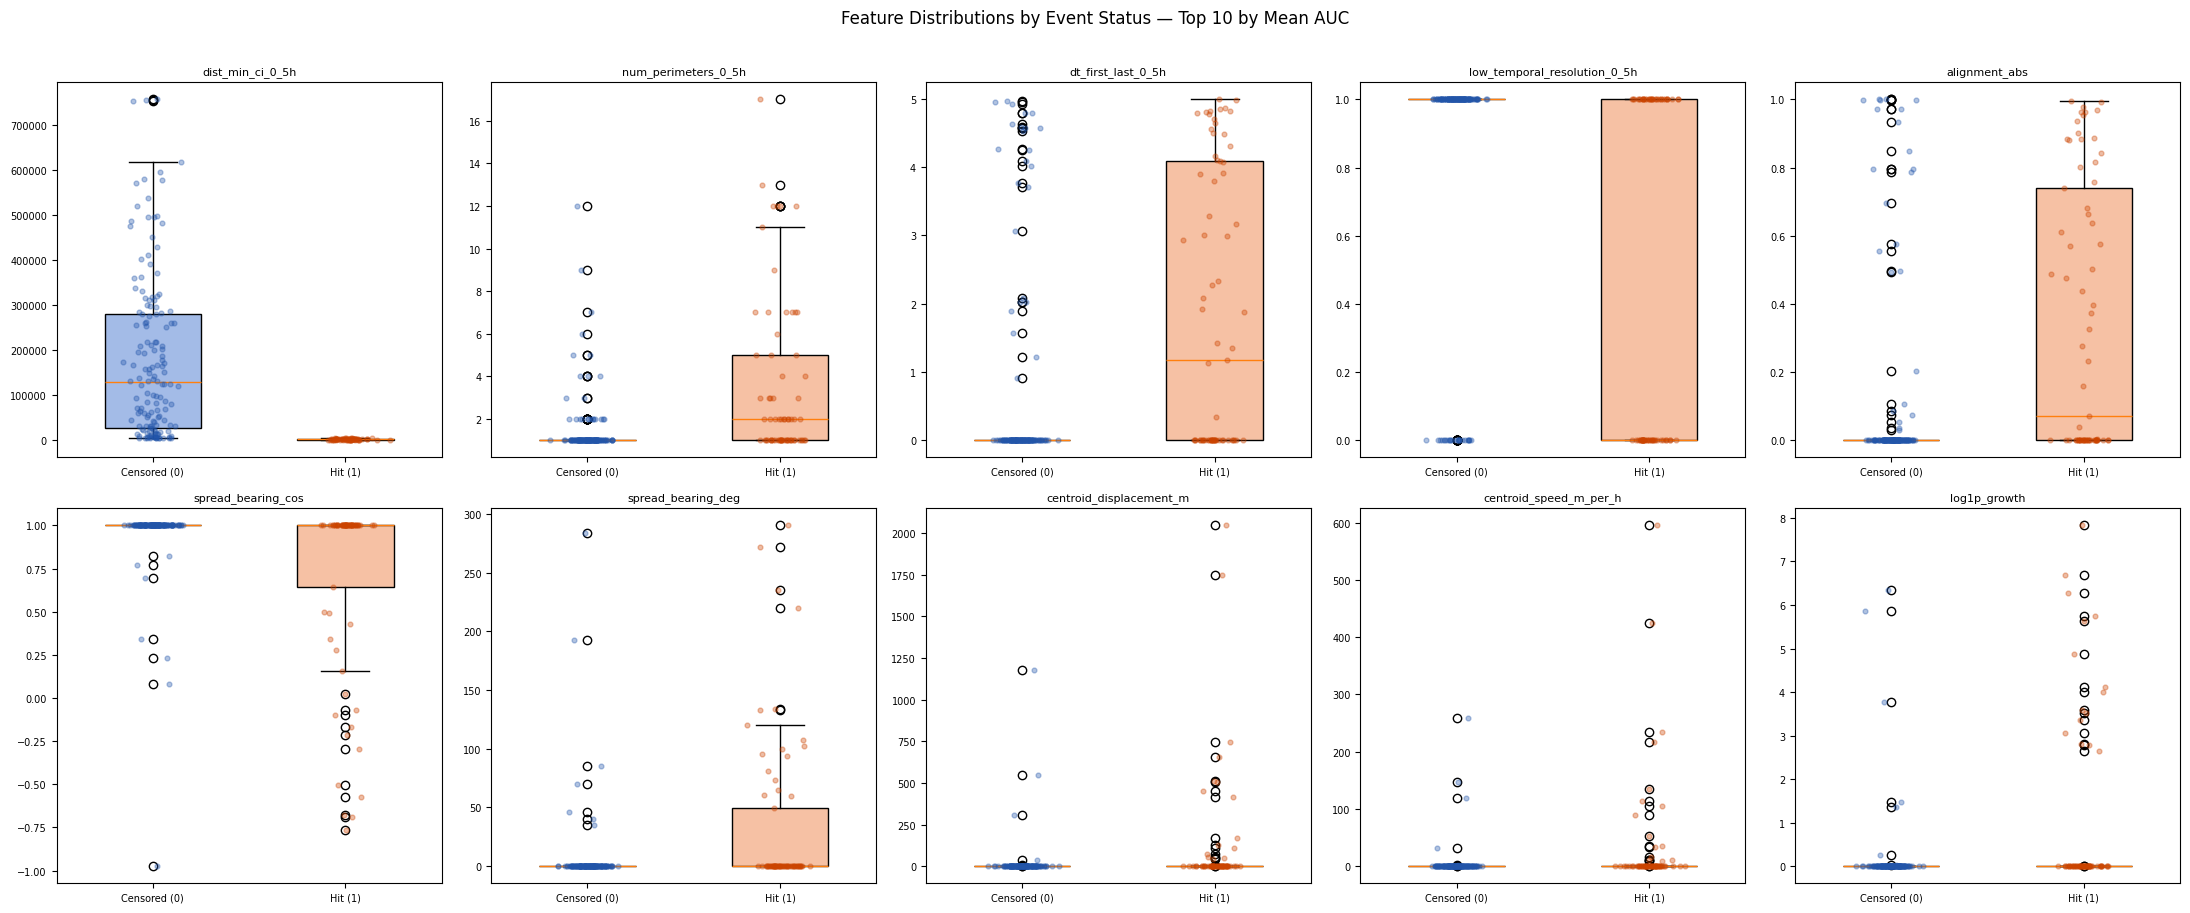

In [29]:
top10_features = horizon_auc_pivot.head(10).index.tolist()

fig, axes = plt.subplots(2, 5, figsize=(22, 9))
axes = axes.flatten()

np.random.seed(42)
for i, col in enumerate(top10_features):
    ax = axes[i]
    e0 = train.loc[train["event"] == 0, col].dropna().values
    e1 = train.loc[train["event"] == 1, col].dropna().values

    bp = ax.boxplot(
        [e0, e1],
        labels=["Censored (0)", "Hit (1)"],
        patch_artist=True,
        widths=0.5,
    )
    bp["boxes"][0].set_facecolor("#4878d080")
    bp["boxes"][1].set_facecolor("#ee854a80")

    for j, (data, color) in enumerate([(e0, "#2255aa"), (e1, "#cc4400")]):
        jitter = np.random.normal(j + 1, 0.06, size=len(data))
        ax.scatter(jitter, data, alpha=0.35, s=12, color=color, zorder=3)

    ax.set_title(col, fontsize=8)
    ax.tick_params(labelsize=7)

plt.suptitle("Feature Distributions by Event Status — Top 10 by Mean AUC", y=1.01)
plt.tight_layout()
plt.show()

In [30]:
overlap_results = []
for col in top10_features:
    x_range = np.linspace(train[col].min(), train[col].max(), 500)
    e0 = train.loc[train["event"] == 0, col]
    e1 = train.loc[train["event"] == 1, col]
    try:
        if len(e0) >= 5 and len(e1) >= 5:
            ov = float(np.trapz(
                np.minimum(gaussian_kde(e0)(x_range), gaussian_kde(e1)(x_range)),
                x_range,
            ))
        else:
            pooled_std = np.sqrt((e0.std() ** 2 + e1.std() ** 2) / 2)
            d = abs(e0.mean() - e1.mean()) / (pooled_std + 1e-9)
            ov = 1 / (1 + d)
    except Exception:
        ov = None
    overlap_results.append({
        "feature": col,
        "kde_overlap": round(ov, 4) if ov is not None else None,
    })

overlap_df = pd.DataFrame(overlap_results).set_index("feature").sort_values("kde_overlap")
display(overlap_df)
most_separable = overlap_df[overlap_df["kde_overlap"] < 0.4].index.tolist()
high_overlap = overlap_df[overlap_df["kde_overlap"] > 0.7].index.tolist()
print(f"\nMOST SEPARABLE (KDE overlap < 0.4):  {most_separable}")
print(f"HIGH OVERLAP   (KDE overlap > 0.7):  {high_overlap}")

,kde_overlap
feature,
dist_min_ci_0_5h,None
num_perimeters_0_5h,None
dt_first_last_0_5h,None
low_temporal_resolution_0_5h,None
alignment_abs,None
spread_bearing_cos,None
spread_bearing_deg,None
centroid_displacement_m,None
centroid_speed_m_per_h,None



MOST SEPARABLE (KDE overlap < 0.4):  []
HIGH OVERLAP   (KDE overlap > 0.7):  []


## 12. Actionable Summary

In [31]:
summary_flags = pd.DataFrame(index=feature_cols)
summary_flags["category"] = pd.Series(category_map)
summary_flags["transform_candidate"] = dist_df["skewness"].abs() > 2
summary_flags["zero_inflated"] = dist_df["zero_fraction"] > 0.30
collinear_features = (
    set(high_corr_df["feature_a"]) | set(high_corr_df["feature_b"])
    if len(high_corr_df) > 0 else set()
)
summary_flags["high_collinearity"] = summary_flags.index.isin(collinear_features)
summary_flags["univariate_cindex"] = ci_df["univariate_cindex"]
summary_flags["cox_p_value"] = cox_df["cox_p_value"]
summary_flags["mean_horizon_auc"] = horizon_auc_pivot["mean_AUC"]
summary_flags["kde_overlap"] = overlap_df["kde_overlap"].reindex(summary_flags.index)
summary_flags = summary_flags.sort_values("mean_horizon_auc", ascending=False)
display(summary_flags.round(4))

,category,transform_candidate,zero_inflated,high_collinearity,univariate_cindex,cox_p_value,mean_horizon_auc,kde_overlap
dist_min_ci_0_5h,distance,False,False,False,0.9095,0.0000,0.9637,None
num_perimeters_0_5h,temporal_coverage,True,False,True,0.7177,0.0000,0.7542,None
dt_first_last_0_5h,temporal_coverage,False,True,True,0.7035,0.0000,0.7448,None
low_temporal_resolution_0_5h,temporal_coverage,False,False,True,0.6947,0.0000,0.7362,None
alignment_abs,directionality,False,True,True,0.6992,0.0000,0.7339,None
spread_bearing_cos,centroid_kinematics,True,False,True,0.6186,0.0000,0.6450,None
spread_bearing_deg,centroid_kinematics,True,True,True,0.6173,0.0000,0.6443,None
centroid_displacement_m,centroid_kinematics,True,True,True,0.6192,0.0002,0.6429,None
centroid_speed_m_per_h,centroid_kinematics,True,True,True,0.6191,0.0001,0.6420,None
log1p_growth,growth,True,True,True,0.6130,0.0000,0.6345,None


In [32]:
print("=" * 70)
print("EDA ACTIONABLE SUMMARY")
print("=" * 70)

print("\n--- FEATURE ENGINEERING ---")
tc = summary_flags[summary_flags["transform_candidate"]].index.tolist()
zi = summary_flags[summary_flags["zero_inflated"]].index.tolist()
print(f"Log-transform candidates (|skew|>2):  {tc}")
print(f"Zero-inflated features (>30% zeros):  {zi}")
print(f"Outlier-heavy (>=5% at 3xIQR):        {outlier_heavy}")

print("\n--- COLLINEARITY (prune for Cox/elastic-net; keep all for trees) ---")
for i, g in enumerate(sorted(groups, key=len, reverse=True)):
    print(f"  Group {i + 1}: {sorted(g)}")

print("\n--- SIGNAL QUALITY ---")
print(f"Significant in Cox PH (p<0.05):       {sig_cox}")
print(f"Low-signal features (p>0.3, CI<0.55): {low_signal}")

print("\n--- MODEL SELECTION SIGNALS ---")
print(f"Non-PH warnings (KM curves cross):    {crossing_features}")
eff_n_72 = int(
    horizon_eff_df.loc[horizon_eff_df["horizon_H"] == 72, "n_effective"].iloc[0]
)
print(f"Horizon 72h effective N (post-exclusion): {eff_n_72}")
print("  -> Survival models (all 221 rows) likely outperform a dedicated 72h classifier.")

print("\n--- TOP 10 FEATURES BY MEAN HORIZON AUC ---")
print(summary_flags[["category", "univariate_cindex", "mean_horizon_auc"]].head(10).to_string())

print("\n--- MOST SEPARABLE FEATURES (KDE overlap < 0.4) ---")
print(f"  {most_separable}")

EDA ACTIONABLE SUMMARY

--- FEATURE ENGINEERING ---
Log-transform candidates (|skew|>2):  ['num_perimeters_0_5h', 'spread_bearing_cos', 'spread_bearing_deg', 'centroid_displacement_m', 'centroid_speed_m_per_h', 'log1p_growth', 'area_growth_rate_ha_per_h', 'area_growth_abs_0_5h', 'radial_growth_m', 'radial_growth_rate_m_per_h', 'relative_growth_0_5h', 'log_area_ratio_0_5h', 'area_growth_rel_0_5h', 'area_first_ha', 'dist_std_ci_0_5h', 'dist_fit_r2_0_5h', 'dist_slope_ci_0_5h', 'closing_speed_abs_m_per_h', 'cross_track_component', 'dist_accel_m_per_h2', 'along_track_speed', 'closing_speed_m_per_h', 'projected_advance_m', 'dist_change_ci_0_5h']
Zero-inflated features (>30% zeros):  ['dt_first_last_0_5h', 'alignment_abs', 'spread_bearing_deg', 'centroid_displacement_m', 'centroid_speed_m_per_h', 'log1p_growth', 'area_growth_rate_ha_per_h', 'area_growth_abs_0_5h', 'radial_growth_m', 'radial_growth_rate_m_per_h', 'relative_growth_0_5h', 'log_area_ratio_0_5h', 'area_growth_rel_0_5h', 'dist_std_